In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import transforms
from PIL import Image

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super(PatchEmbedding, self).__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Conv2d로 패치 생성 (Conv로 하면 자동으로 패치 분할 + 선형 임베딩)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # 위치 임베딩 (Positional Encoding)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        
    def forward(self, x):
        # 입력 이미지 크기: (B, 3, 224, 224)
        x = self.proj(x)  # (B, embed_dim, 14, 14)
        x = x.flatten(2)  # (B, embed_dim, 196)
        x = x.transpose(1, 2)  # (B, 196, embed_dim)
        
        # 위치 임베딩 추가
        x = x + self.pos_embed
        return x


In [4]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, mlp_dim=2048, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        
        # Feedforward 네트워크
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-Attention
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output  # Residual 연결
        x = self.norm1(x)
        
        # Feedforward Network
        mlp_output = self.mlp(x)
        x = x + mlp_output  # Residual 연결
        x = self.norm2(x)
        
        return x


In [5]:
class ViTEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768, depth=6, num_heads=8, mlp_dim=2048):
        super(ViTEncoder, self).__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.patch_embed(x)  # 패치 임베딩 + 위치 임베딩
        
        # Transformer 인코더 블록 반복
        for block in self.transformer_blocks:
            x = block(x)
        
        # 최종 Layer Normalization
        x = self.norm(x)
        return x  # (B, 196, embed_dim)


In [6]:
# 더미 이미지 데이터 생성 (배치 크기=1, 채널=3, 224x224)
dummy_img = torch.randn(1, 3, 224, 224)

# 모델 초기화
vit_encoder = ViTEncoder()

# 모델 실행
with torch.no_grad():
    embeddings = vit_encoder(dummy_img)

print(f"임베딩 출력 크기: {embeddings.shape}")


임베딩 출력 크기: torch.Size([1, 196, 768])


In [8]:
# 무작위로 패치 중 25% 마스킹
mask_ratio = 0.25
num_patches = embeddings.shape[1]
num_masked = int(mask_ratio * num_patches)

# 마스킹할 인덱스 선택
mask_indices = np.random.choice(num_patches, num_masked, replace=False)
mask = torch.ones(embeddings.shape)
mask[:, mask_indices, :] = 0  # 마스크된 부분은 0으로 설정

# 마스크 적용
masked_embeddings = embeddings * mask

# 예측기 (단순 MLP로 구현)
predictor = nn.Linear(768, 768)
predicted_embeddings = predictor(masked_embeddings)

# 손실(L1 Loss) 계산
loss_fn = nn.L1Loss()
loss = loss_fn(predicted_embeddings, embeddings)

print(f"예측 손실 (L1 Loss): {loss.item()}")


예측 손실 (L1 Loss): 0.8884469270706177


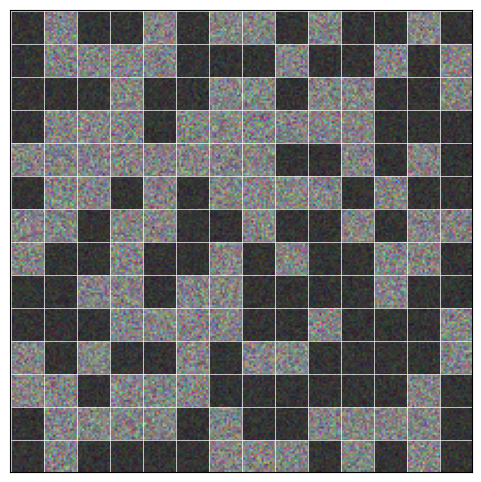

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# 1. 더미 이미지 생성 (랜덤 노이즈 이미지)
img_size = 224
dummy_img = torch.randn(1, 3, img_size, img_size)

# 2. 패치 분할 및 시각화 함수
def show_image_with_patches(img_tensor, patch_size=16, mask_indices=None):
    img = img_tensor.squeeze().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)

    num_patches = img_size // patch_size

    # 패치 경계 표시
    for i in range(0, img_size, patch_size):
        ax.axhline(i, color='white', linewidth=0.5)
        ax.axvline(i, color='white', linewidth=0.5)

    # 마스킹된 패치 표시
    if mask_indices is not None:
        for idx in mask_indices:
            row = idx // num_patches
            col = idx % num_patches
            rect = plt.Rectangle((col * patch_size, row * patch_size), patch_size, patch_size,
                                 facecolor='black', alpha=0.6)
            ax.add_patch(rect)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# 3. 마스킹 설정
patch_size = 16
num_patches = (img_size // patch_size) ** 2
mask_ratio = 0.5
num_masked = int(mask_ratio * num_patches)
mask_indices = np.random.choice(num_patches, num_masked, replace=False)

# 4. 시각화 실행
show_image_with_patches(dummy_img, patch_size=patch_size, mask_indices=mask_indices)


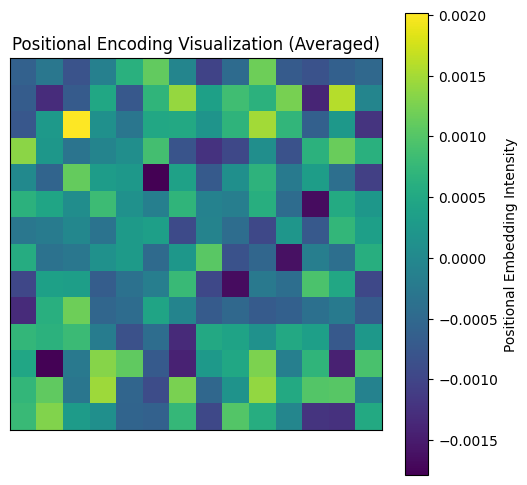

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. 위치 임베딩 초기화
img_size = 224
patch_size = 16
num_patches = (img_size // patch_size) ** 2
embed_dim = 768

# 학습 가능한 위치 임베딩 생성
pos_embed = torch.nn.Parameter(torch.zeros(1, num_patches, embed_dim))

# 초기화 (작은 정규분포로 랜덤 초기화)
torch.nn.init.normal_(pos_embed, mean=0.0, std=0.02)

# 2. 2D 시각화를 위해 평균값 계산
# 각 패치의 768차원 벡터를 평균내어 1개의 값으로 축소
pos_embed_2d = pos_embed[0].mean(dim=1).reshape(img_size // patch_size, img_size // patch_size)

# 3. 시각화
plt.figure(figsize=(6, 6))
plt.imshow(pos_embed_2d.detach().numpy(), cmap='viridis')
plt.colorbar(label='Positional Embedding Intensity')
plt.title('Positional Encoding Visualization (Averaged)')
plt.xticks([])
plt.yticks([])
plt.show()
